# 02 — Clean the Data & Engineer Features

**Goal of this notebook:**
1. Run the cleaning pipeline (drop junk columns, keep only real run/pass plays).
2. Build the **coordinator-level target**: ~10 play concepts (screens, play-action shots, inside runs...) plus formation and personnel labels.
3. Build **rolling team-form features** — how good each offense and defense has been over the *previous 4 weeks*.
4. Sanity-check everything with charts: do the numbers match what we know about the league?

**Why rolling features?** A play call should depend on *who you're playing*. "The Jets' defense has allowed -0.1 EPA per pass over the last month" is exactly the kind of info a coordinator uses. We use only **previous** weeks so the model never peeks at the future (no data leakage).

## Setup and reload the raw data

Same import-path trick as notebook 01, then run the loader again. (Each notebook is self-contained so you can open it fresh.)

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_data
from src.data.cleaner import clean_data
from src.data.concepts import add_play_concepts
from src.data.features import add_team_features, build_offense_stats, build_defense_stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

raw = load_data()

LOADING DATA
Loading play_by_play_2023.csv.gz ...
Loading play_by_play_2024.csv.gz ...
Loading play_by_play_2025.csv.gz ...
Loading participation_2023.csv ...
Loading participation_2024.csv ...
Loading participation_2025.csv ...
Loading ftn_charting_2023.csv ...
Loading ftn_charting_2024.csv ...
Loading ftn_charting_2025.csv ...
Participation data matched on 109,717 of 147,928 plays.
FTN charting matched on 143,572 of 147,928 plays.
------------------------------------------------------------
Combined shape : 147,928 rows x 393 columns
Memory usage   : 1,240 MB
Plays per season:
season
2023    49665
2024    49492
2025    48771


## Step 1: Clean

`clean_data()` does four things (open `src/data/cleaner.py` to see the code):
1. Drops columns that are **95%+ null** (punt/kick details that don't apply to normal plays).
2. Keeps only `play_type` in `['run', 'pass']` — the actual play-calling decisions.
3. Removes rows with a null `down` (kickoffs/PATs that sneak through) plus **kneels** and **spikes** (clock management, not strategy).
4. Keeps ~60 curated columns: game state, formation, outcomes, scoring probabilities, drive context, advanced metrics.

Watch the before/after counts it prints — we go from ~390 columns to ~60, and lose the non-play rows.

In [2]:
before_shape = raw.shape
df = clean_data(raw)

print(f'\nBefore: {before_shape[0]:,} rows x {before_shape[1]} cols')
print(f'After : {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Kept {df.shape[0] / before_shape[0]:.0%} of rows, {df.shape[1] / before_shape[1]:.0%} of columns')

CLEANING DATA
Dropped 87 columns that were 95%+ null.
------------------------------------------------------------
Rows    : 147,928 -> 104,880
Columns : 393 -> 85

play_type value counts (should be only run/pass):
play_type
pass    60181
run     44699

Before: 147,928 rows x 393 cols
After : 104,880 rows x 85 cols
Kept 71% of rows, 22% of columns


## Step 2: Build play concepts — the coordinator-level target

Run vs pass is too coarse for a real play caller. `add_play_concepts()` (see `src/data/concepts.py`) uses the **FTN charting data** (play-action, screens, sneaks, trick plays) plus the pbp pass depth / run gap columns to build a ~10-class target:

| Passes | Runs | Other |
|---|---|---|
| `short_pass`, `deep_pass` | `inside_run` (guard/middle) | `trick_play` |
| `pa_short_pass`, `pa_deep_pass` (play action) | `off_tackle_run` | |
| `screen_pass` | `outside_run` (end), `qb_sneak` | |

`play_concept_detailed` adds direction (left/middle/right) for ~28 classes.

It also adds:
- **`formation`** — from FTN's QB alignment + backfield count (`shotgun_1back`, `under_center_2back`, `empty`...).
- **`personnel`** — the standard 2-digit code (`11` = 1 RB, 1 TE) parsed from the participation data. Both cover all our seasons.

A few plays stay unlabeled on purpose: QB scrambles and sacks with no recorded pass depth — we can't know what was actually called, so they're excluded from training rather than guessed.

In [3]:
df = add_play_concepts(df)

# How do play calls differ by down? (rows = down, cols = concept, values = % of plays)
pd.crosstab(df['down'], df['play_concept'], normalize='index').round(2)

BUILDING PLAY CONCEPTS (formation / personnel / concept)
formation    : 103,410 of 104,880 plays labeled
personnel    : 101,585 of 104,880 plays labeled
play_concept : 97,032 of 104,880 plays labeled

play_concept class counts:
play_concept
short_pass        32011
inside_run        20637
off_tackle_run     9791
outside_run        9140
pa_short_pass      7910
deep_pass          7637
screen_pass        5601
pa_deep_pass       2608
qb_sneak            951
trick_play          746

play_concept_detailed has 28 classes


play_concept,deep_pass,inside_run,off_tackle_run,outside_run,pa_deep_pass,pa_short_pass,qb_sneak,screen_pass,short_pass,trick_play
down,,,,,,,,,,
1.0,0.05,0.26,0.13,0.12,0.04,0.11,0.00,0.05,0.22,0.01
2.0,0.07,0.21,0.10,0.09,0.03,0.08,0.00,0.07,0.35,0.01
3.0,0.15,0.12,0.04,0.04,0.00,0.02,0.03,0.06,0.54,0.00
4.0,0.14,0.14,0.04,0.07,0.01,0.04,0.11,0.01,0.42,0.02


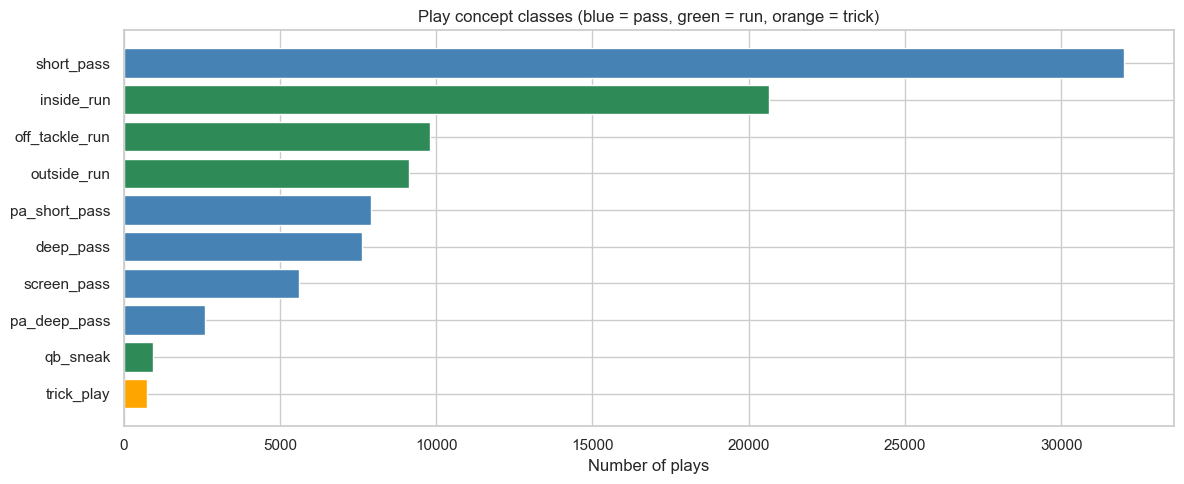

In [4]:
# Visualize the class balance - the model will need to handle the imbalance
# (short passes are ~3x more common than deep passes)
concept_counts = df['play_concept'].value_counts()

fig, ax = plt.subplots()
colors = ['steelblue' if 'pass' in c else 'seagreen' if 'run' in c or c == 'qb_sneak' else 'orange'
          for c in concept_counts.index]
ax.barh(concept_counts.index[::-1], concept_counts.values[::-1],
        color=colors[::-1])
ax.set_xlabel('Number of plays')
ax.set_title('Play concept classes (blue = pass, green = run, orange = trick)')
plt.tight_layout()
plt.show()

## Step 2: Build rolling team features

`add_team_features()` builds, for every team and week:
- **Offense:** EPA/play (overall, pass-only, run-only), success rate, pass rate, yards/play
- **Defense:** the same stats *allowed* to opponents

Each number is the average of the **previous 4 weeks** (`.shift(1).rolling(4)`), so a week-10 play is described by weeks 6–9. Week-1 games have no history and get filled with the season average.

It also saves the final dataframe to `data/processed/pbp_features.csv` — that's the file the model trains on.

In [5]:
df = add_team_features(df, save=True)

# The new columns all start with off_ or def_
feature_cols = [c for c in df.columns if c.startswith(('off_', 'def_'))]
df[feature_cols].describe().round(3)

BUILDING TEAM FEATURES (rolling previous-4-week form)
Offense stats : 1,710 team-week rows
Defense stats : 1,710 team-week rows
Added 11 team-form feature columns.
Saved -> c:\Users\ajguz\Desktop\PlayCaller\data\processed\pbp_features.csv
Final shape: 104,880 rows x 100 columns


,off_epa_per_play,off_epa_pass,off_epa_run,off_success_rate,off_pass_rate,off_yards_per_play,def_epa_allowed_per_play,def_epa_allowed_pass,def_epa_allowed_run,def_success_rate_allowed,def_yards_allowed_per_play
count,104880.000,104880.000,104880.000,104880.000,104880.000,104880.000,104880.000,104880.000,104880.000,104880.000,104880.000
mean,-0.007,0.019,-0.034,0.433,0.574,5.428,-0.013,0.011,-0.037,0.431,5.405
std,0.134,0.199,0.129,0.048,0.064,0.774,0.123,0.186,0.124,0.045,0.691
min,-0.488,-0.749,-0.841,0.212,0.362,2.418,-0.522,-0.749,-0.841,0.212,2.418
25%,-0.090,-0.101,-0.107,0.402,0.532,4.961,-0.088,-0.106,-0.112,0.403,4.981
50%,0.001,0.032,-0.028,0.435,0.575,5.440,-0.010,0.015,-0.031,0.433,5.413
75%,0.081,0.138,0.048,0.465,0.618,5.875,0.065,0.128,0.042,0.461,5.818
max,0.388,0.702,0.524,0.595,0.833,8.640,0.386,0.664,0.524,0.579,8.640


## Sanity check: one team's rolling form

Let's look at the **2023 Kansas City Chiefs**, week by week. The numbers should move smoothly (it's a 4-week average) and look like a good-but-not-dominant offense — 2023 KC won the Super Bowl on defense, with a shaky receiving corps.

In [6]:
off_stats = build_offense_stats(df)

kc_2023 = off_stats[(off_stats['posteam'] == 'KC') & (off_stats['season'] == 2023)]
kc_2023.round(3)

,season,week,posteam,off_epa_per_play,off_epa_pass,off_epa_run,off_success_rate,off_pass_rate,off_yards_per_play
15,2023,1,KC,NaN,NaN,NaN,NaN,NaN,NaN
47,2023,2,KC,-0.146,-0.165,-0.112,0.403,0.629,5.097
79,2023,3,KC,-0.000,-0.031,0.062,0.398,0.659,5.868
111,2023,4,KC,0.078,0.104,0.070,0.439,0.613,5.999
142,2023,5,KC,0.101,0.083,0.129,0.450,0.581,6.073
170,2023,6,KC,0.180,0.212,0.110,0.461,0.590,6.121
197,2023,7,KC,0.137,0.211,-0.011,0.489,0.578,5.920
227,2023,8,KC,0.142,0.216,-0.048,0.488,0.622,6.310
256,2023,9,KC,0.021,0.110,-0.149,0.464,0.680,5.938
313,2023,11,KC,-0.018,0.033,-0.107,0.461,0.665,5.890


## Plot: offensive EPA over the season

Comparing three 2023 offenses we know the story for:
- **SF** — elite, should sit near the top
- **KC** — good but inconsistent that year
- **NYJ** — Aaron Rodgers tore his Achilles in week 1; should be rough

If the lines match that story, our feature pipeline is working.

## What we built

- A clean dataset of ~105k plays with ~100 columns, saved to `data/processed/pbp_features.csv`.
- A **10-class play-concept target** (plus a 28-class detailed version with direction) built from FTN charting — this is what makes the project a play *caller* instead of a run/pass classifier.
- `formation` labels (FTN) and `personnel` codes (participation data) for all seasons.
- 11 rolling team-form features with **no data leakage** — every play is described only by what was known *before* that week.
- Visual confirmation that the features track real team quality.

**Next:** `04_model_training.ipynb` (Phase 2) — train XGBoost to predict `play_concept` success and turn it into a recommender.

## Plot: defensive EPA allowed

Same idea for defenses. **Lower is better** here (negative EPA allowed = the defense is taking points off the board).
- **BAL** — elite 2023 defense, should be low
- **CLE** — also a top defense that year
- **WAS** — one of the worst, should be high

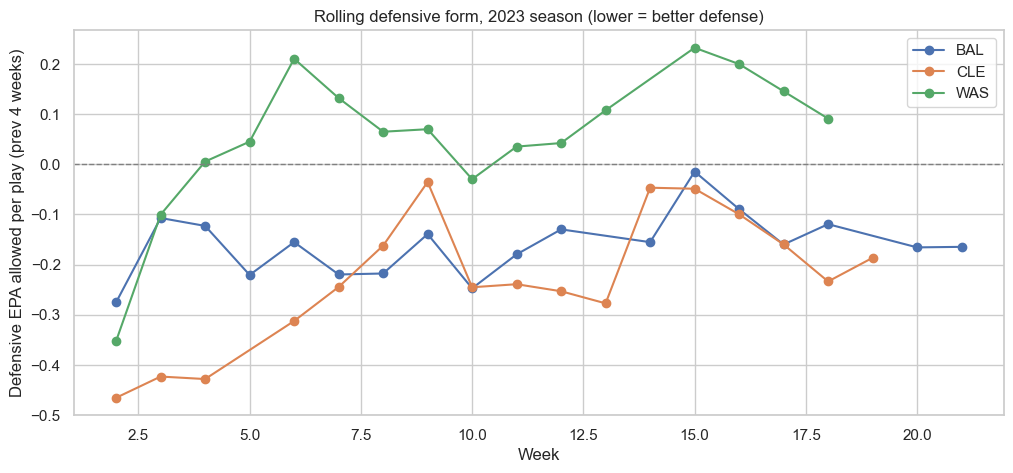

In [8]:
def_stats = build_defense_stats(df)
teams = ['BAL', 'CLE', 'WAS']

fig, ax = plt.subplots()
for team in teams:
    d = def_stats[(def_stats['defteam'] == team) & (def_stats['season'] == 2023)]
    ax.plot(d['week'], d['def_epa_allowed_per_play'], marker='o', label=team)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Week')
ax.set_ylabel('Defensive EPA allowed per play (prev 4 weeks)')
ax.set_title('Rolling defensive form, 2023 season (lower = better defense)')
ax.legend()
plt.show()

## What we built

- A clean dataset of run/pass plays with ~70 columns, saved to `data/processed/pbp_features.csv`.
- 11 rolling team-form features with **no data leakage** — every play is described only by what was known *before* that week.
- Visual confirmation that the features track real team quality.

**Next:** `04_model_training.ipynb` (Phase 2) — train XGBoost to predict play success and turn it into a recommender.